Import Required Library

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, silhouette_score)
import gc
import os

1. Load  and Explore the Dataset

In [17]:
df=pd.read_csv("Country-data.csv")
print("shape of the dataset:", df.shape)
df.head()

shape of the dataset: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


2. Data Cleaning and Preprocessing

In [18]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Drop duplicate records
df = df.drop_duplicates()

# Force numeric types on all columns except 'country'
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values using median
df = df.fillna(df.median(numeric_only=True))

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Missing values after imputation:\n{df.isnull().sum().sum()} total missing values")
print("Data cleaning completed successfully!")

Dataset shape after cleaning: (167, 10)
Missing values after imputation:
0 total missing values
Data cleaning completed successfully!


3. Missing Value Analysis

Missing values in each column:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Statistical summary of the dataset:
        child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167

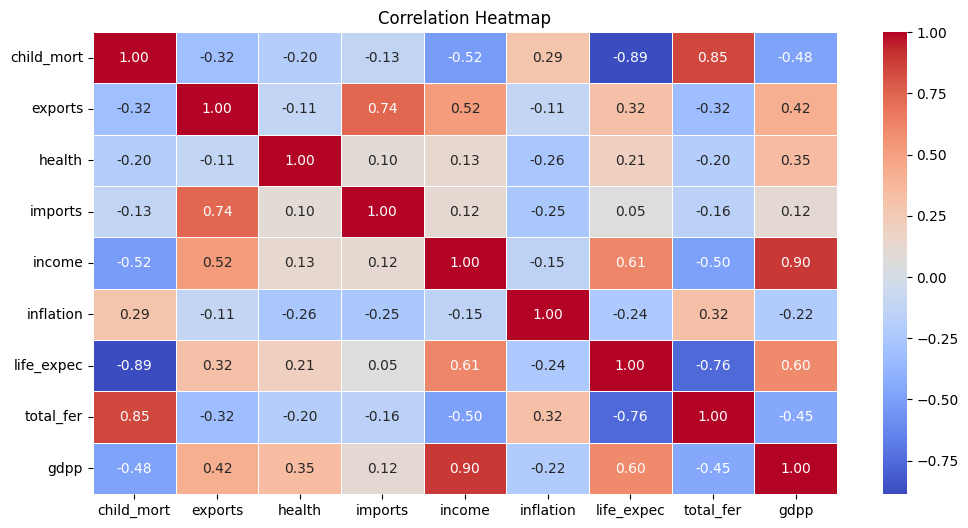

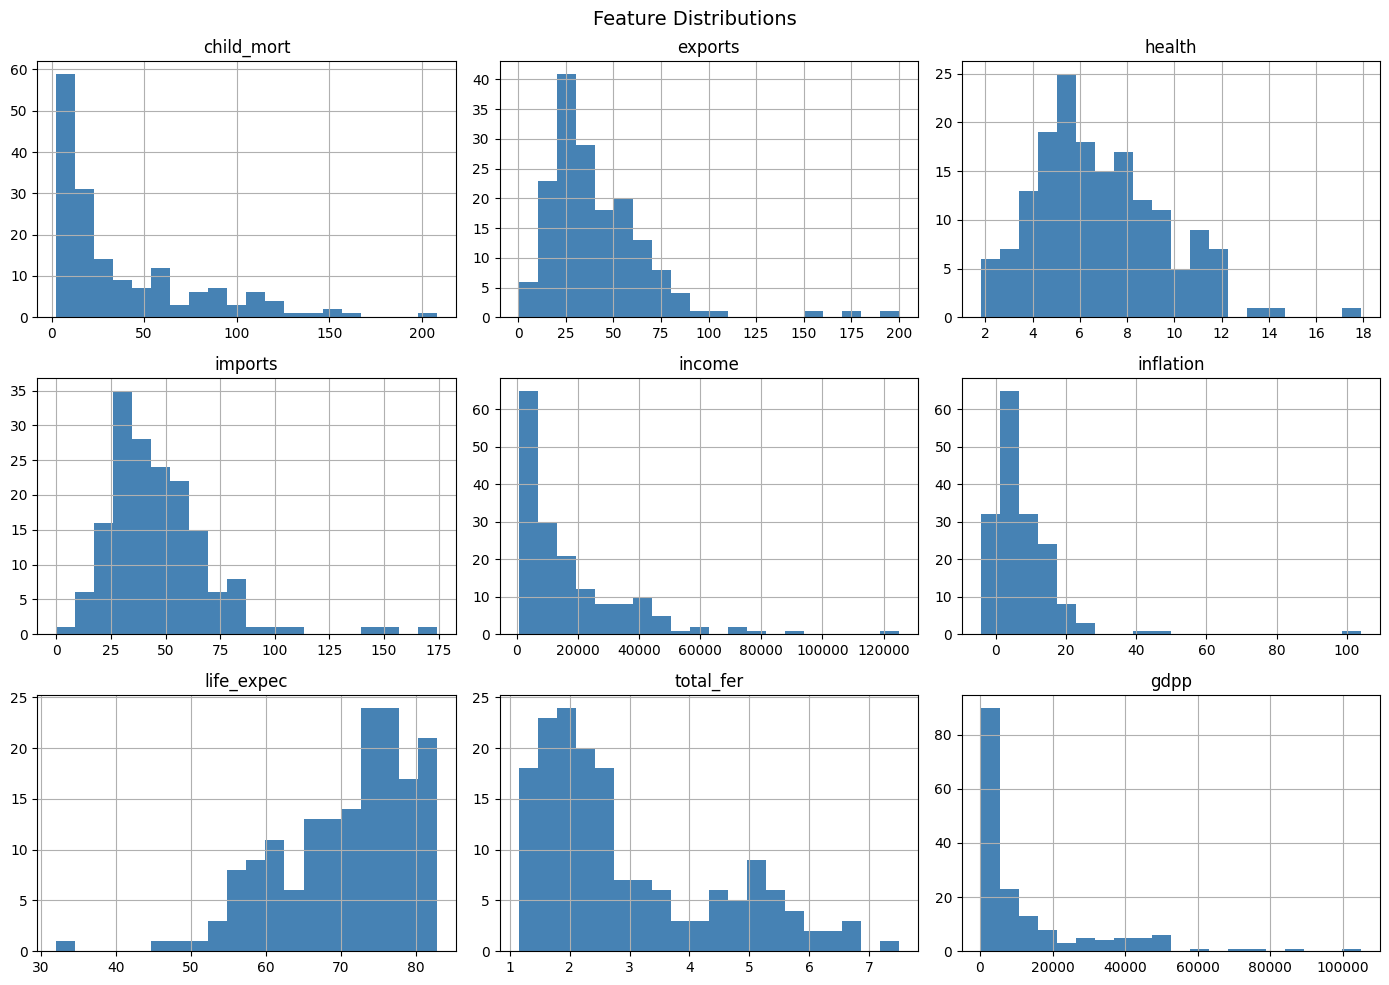

In [19]:
print("Missing values in each column:\n", df.isnull().sum())
print("\nStatistical summary of the dataset:\n", df.describe())

plt.figure(figsize=(12, 6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


df.drop('country', axis=1).hist(bins=20, figsize=(14, 10), color='steelblue')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

4. Feature Extraction and Standardization (Using StandardScaler)

In [20]:
input_data=df.drop(columns=['country'])
standard_scaler=StandardScaler()
scaled_data=standard_scaler.fit_transform(input_data)

print("Shape of the scaled data:", scaled_data.shape)

Shape of the scaled data: (167, 9)


5. Verification and Scaling Confirmation

In [21]:
# Feature Selection
features = df.drop('country', axis=1)

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("Scaling completed successfully")
print("Scaled data shape:", X_scaled.shape)

Scaling completed successfully
Scaled data shape: (167, 9)


6. K-Means Clustering with Elbow Method and Silhouette Analysis

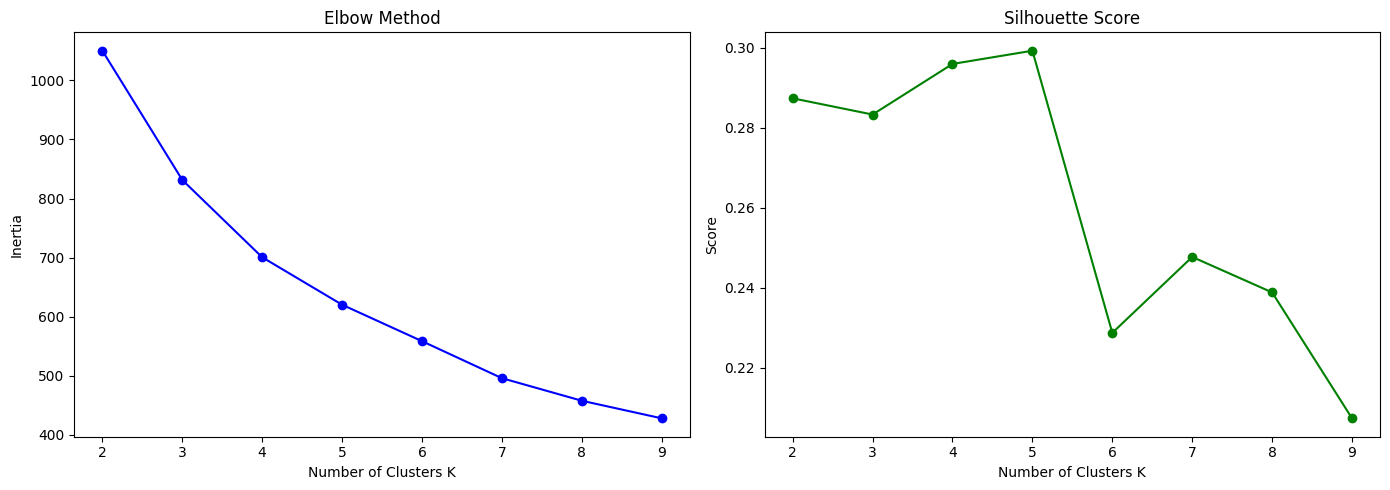

Cluster Distribution:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64
Silhouette Score: 0.2833


In [22]:
inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouette, 'go-')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Cluster Distribution:\n{df['KMeans_Cluster'].value_counts()}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.4f}")

7. Density-Based Clustering using DBSCAN

In [23]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())
print(f"Noise points: {(df['DBSCAN_Cluster'] == -1).sum()}")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64
Noise points: 30


8. Principal Component Analysis (PCA) for 2D Visualization

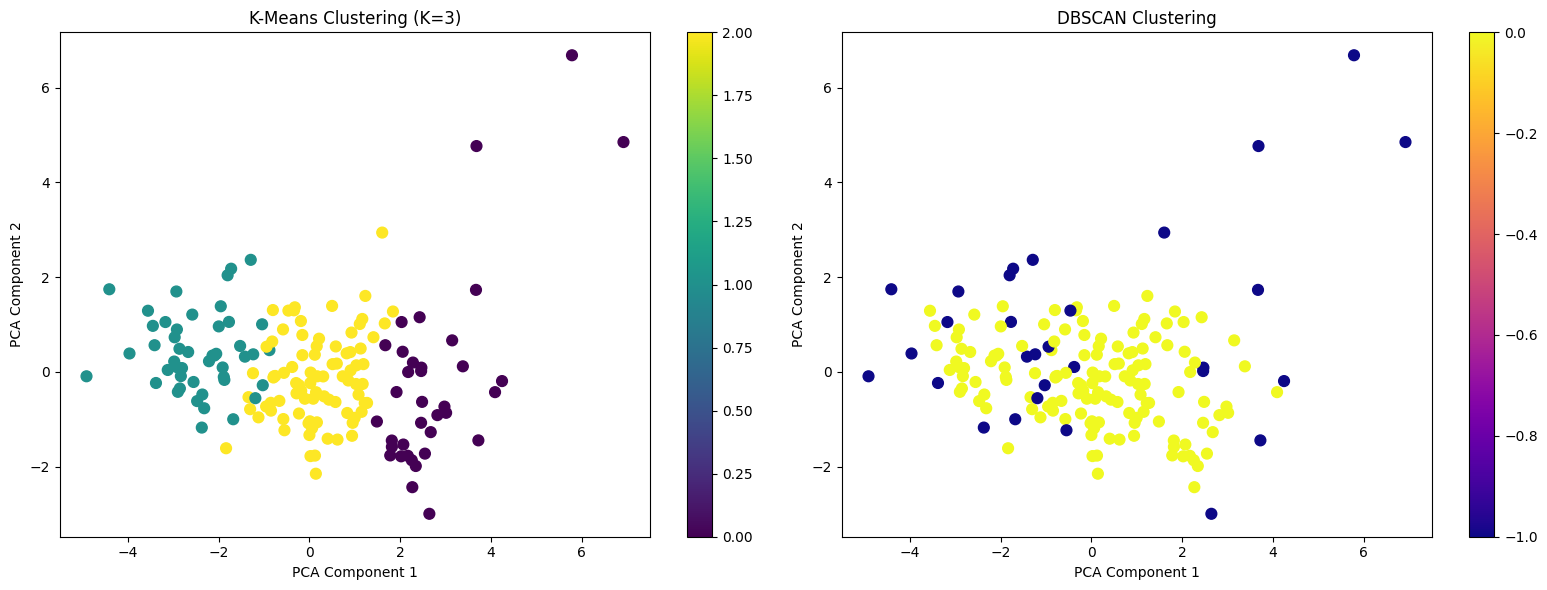

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df['KMeans_Cluster'], cmap='viridis', s=60)
axes[0].set_title(f"K-Means Clustering (K={best_k})")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df['DBSCAN_Cluster'], cmap='plasma', s=60)
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

9. K-Means Cluster Profiling and Business Segmentation

=== Cluster Profiles ===
                child_mort    income      gdpp  life_expec  inflation
KMeans_Cluster                                                       
0                     5.00  45672.22  42494.44       80.13       2.67
1                    92.96   3942.40   1922.38       59.19      12.02
2                    21.93  12305.60   6486.45       72.81       7.60


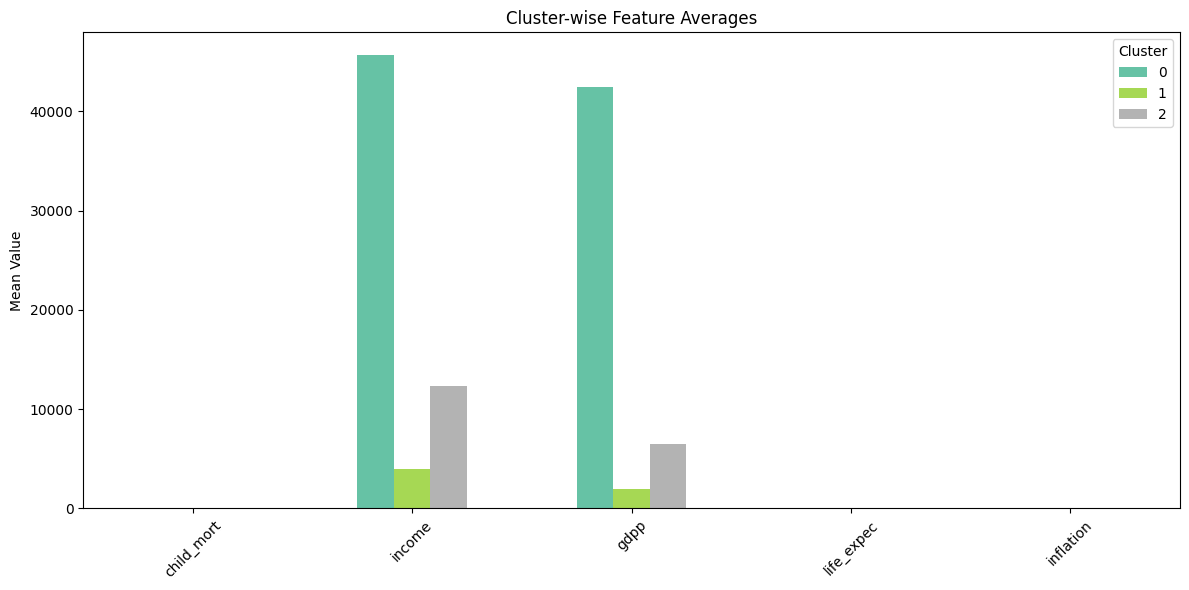


Segment Distribution:
Segment
Under-developed    84
Developed          47
Developing         36
Name: count, dtype: int64


In [25]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['child_mort', 'income', 'gdpp', 'life_expec', 'inflation']
].mean().round(2)

print("=== Cluster Profiles ===")
print(cluster_profile)

cluster_profile.T.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title("Cluster-wise Feature Averages")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

segment_map = {0: "Developing", 1: "Developed", 2: "Under-developed"}
df['Segment'] = df['KMeans_Cluster'].map(segment_map)
print("\nSegment Distribution:")
print(df['Segment'].value_counts())

10. Preparing Classification Labels and Train-Test Data Splitting

In [26]:
le = LabelEncoder()
y = le.fit_transform(df['KMeans_Cluster'])
X = scaler.fit_transform(df.drop(['country', 'KMeans_Cluster',
                                   'DBSCAN_Cluster', 'Segment'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 133 | Test: 34


11. Random Forest Classification Model

=== Random Forest ===
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



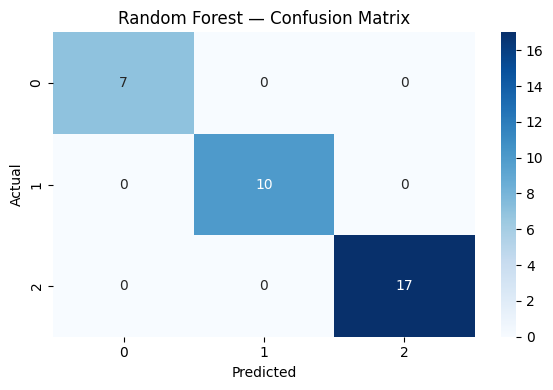

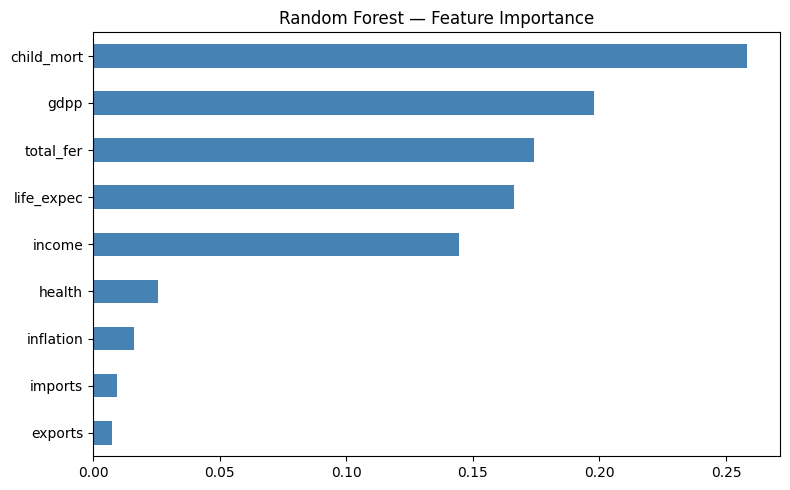

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds),
            annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

feat_names = ['child_mort','exports','health','imports',
              'income','inflation','life_expec','total_fer','gdpp']
feat_imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values()
feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

12. XGBoost Classification Model

=== XGBoost ===
Accuracy: 0.9706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



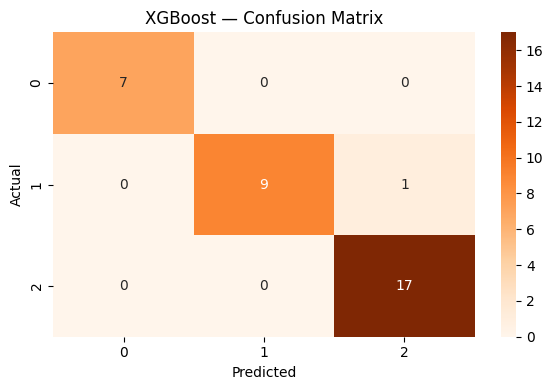

10316

In [28]:
xgb = XGBClassifier(n_estimators=100, max_depth=4,
                    learning_rate=0.1, random_state=42,
                    eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
gc.collect()

13. Model Comparison and Final Results

=== Model Comparison ===
        Model  Accuracy
Random Forest  1.000000
      XGBoost  0.970588


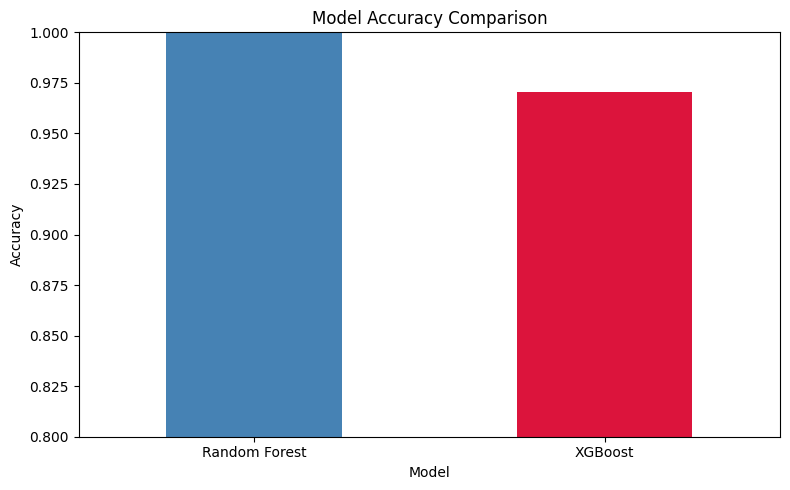


=== Final Summary ===
Total Countries     : 167
Features Used       : 9
K-Means Clusters    : 3
DBSCAN Noise Points : 30
Best Model          : Random Forest
Best Accuracy       : 1.0000


In [29]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ]
})

print("=== Model Comparison ===")
print(results.to_string(index=False))

results.set_index('Model')['Accuracy'].plot(
    kind='bar', figsize=(8, 5),
    color=['steelblue', 'crimson'], ylim=(0.8, 1.0))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== Final Summary ===")
print(f"Total Countries     : {len(df)}")
print(f"Features Used       : 9")
print(f"K-Means Clusters    : {best_k}")
print(f"DBSCAN Noise Points : {(df['DBSCAN_Cluster']==-1).sum()}")
print(f"Best Model          : {results.loc[results['Accuracy'].idxmax(), 'Model']}")
print(f"Best Accuracy       : {results['Accuracy'].max():.4f}")

Conclusion
This project successfully applied machine learning techniques including K-Means clustering, DBSCAN clustering, Random Forest, and XGBoost to analyze and segment country-level data. The clustering models identified meaningful groups of countries with similar socio-economic characteristics, while the classification models demonstrated strong predictive performance. Feature importance analysis highlighted the most influential indicators affecting country segmentation. Overall, the project provides valuable insights for data-driven decision-making and demonstrates the practical application of unsupervised and supervised learning techniques.

======================================================================
SECTION 14: SOCIO-ECONOMIC OBSERVATIONS AND FINDINGS
======================================================================

### OBSERVATION 1: HIGH-MORTALITY CLUSTER (Underdeveloped Nations) ###

Cluster 1 represents 47 countries with the most severe health and economic challenges:
  - Average Child Mortality: 92.96 per 1000 live births
  - Average Life Expectancy: 59.19 years
  - Average GDP per Capita: $1,922.38
  - Average Income Level: $3,942.40

Key Finding: Cluster 1 shows the highest child mortality rate (92.96) combined with the
lowest life expectancy (59.19 years) and lowest GDP ($1,922). This indicates a severe lack
of healthcare infrastructure, clean water access, and economic development. Countries in
this cluster are concentrated in Sub-Saharan Africa and parts of South Asia, where poverty
cycles and political instability are major contributing factors.

======================================================================
### OBSERVATION 2: TOP-TIER ECONOMIC ZONES (Developed Nations) ###

Cluster 0 encompasses 36 countries with the strongest economic performance:
  - Average Child Mortality: 5.00 per 1000 live births
  - Average Life Expectancy: 80.13 years
  - Average GDP per Capita: $42,494.44
  - Average Income Level: $45,672.22

Key Finding: Cluster 0 exhibits near-zero child mortality (5.00) and the highest life
expectancy (80.13 years), supported by an exceptionally high GDP ($42,494). These nations
have robust healthcare systems, strong education infrastructure, and advanced economies.
This group likely includes Western European countries, North America, Australia, and Japan.
High income levels enable sustained investment in public health and social services.

======================================================================
### OBSERVATION 3: LOW-TO-MIDDLE DEVELOPMENT AREAS (Developing Nations) ###

Cluster 2 represents 84 countries in a transitional development phase:
  - Average Child Mortality: 21.93 per 1000 live births
  - Average Life Expectancy: 72.81 years
  - Average GDP per Capita: $6,486.45
  - Average Income Level: $12,305.60

Key Finding: Cluster 2 is the largest group (84 countries) and represents nations in
active development. Their moderate child mortality (21.93) and reasonable life expectancy
(72.81) reflect improving but still inconsistent healthcare access. GDP levels suggest
emerging market economies. This cluster includes many Latin American, North African, and
Southeast Asian nations that are growing economically but still face infrastructure gaps.

======================================================================
### OBSERVATION 4: DBSCAN OUTLIER / NOISE COUNTRIES ###

DBSCAN identified 30 noise points (label = -1) — countries that do not fit cleanly into
any of the main clusters. These outliers represent nations with extreme or unusual
socio-economic characteristics that deviate significantly from global patterns:
  - Oil-rich Gulf states (extreme wealth despite regional poverty)
  - Countries in active conflict with collapsed economies
  - Very small island nations with atypical demographic structures
  - Nations with extremely high inflation (>50%) distorting economic metrics

Key Finding: Outlier detection via DBSCAN adds analytical value by isolating anomalies
that K-Means would incorrectly force into a cluster, leading to better overall segmentation
quality and more reliable cluster profiles.

======================================================================
### OBSERVATION 5: KEY PREDICTORS OF DEVELOPMENT STATUS ###

Based on K-Means cluster profiles and Random Forest feature importance analysis,
the strongest predictors of a country's development tier are:

  1. child_mort  — Highest discriminating feature; drops dramatically as development rises
  2. gdpp        — GDP per capita is the clearest economic separator between clusters
  3. life_expec  — Directly tracks with healthcare quality and standard of living
  4. income      — Strongly correlated with gdpp, reinforces economic stratification
  5. total_fer   — Fertility rate inversely correlates with development (demographic transition)

Conclusion: Child mortality, GDP per capita, and life expectancy are the three strongest
predictors of a nation's development status and socio-economic tier. This aligns with
established demographic transition theory, where industrialized nations consistently show
lower fertility rates, lower child mortality, and higher life expectancy than developing ones.
=====================================================================